# 02 — Exploratory Analysis

Part 1: identifying the series' components (is there a seasonal pattern?) and testing for non-stationarity. Full generation code is in `scripts/eda_and_stationarity.py`; this notebook displays the resulting figures and stationarity summary.

In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
from IPython.display import Image, display


## Full series and seasonal zoom

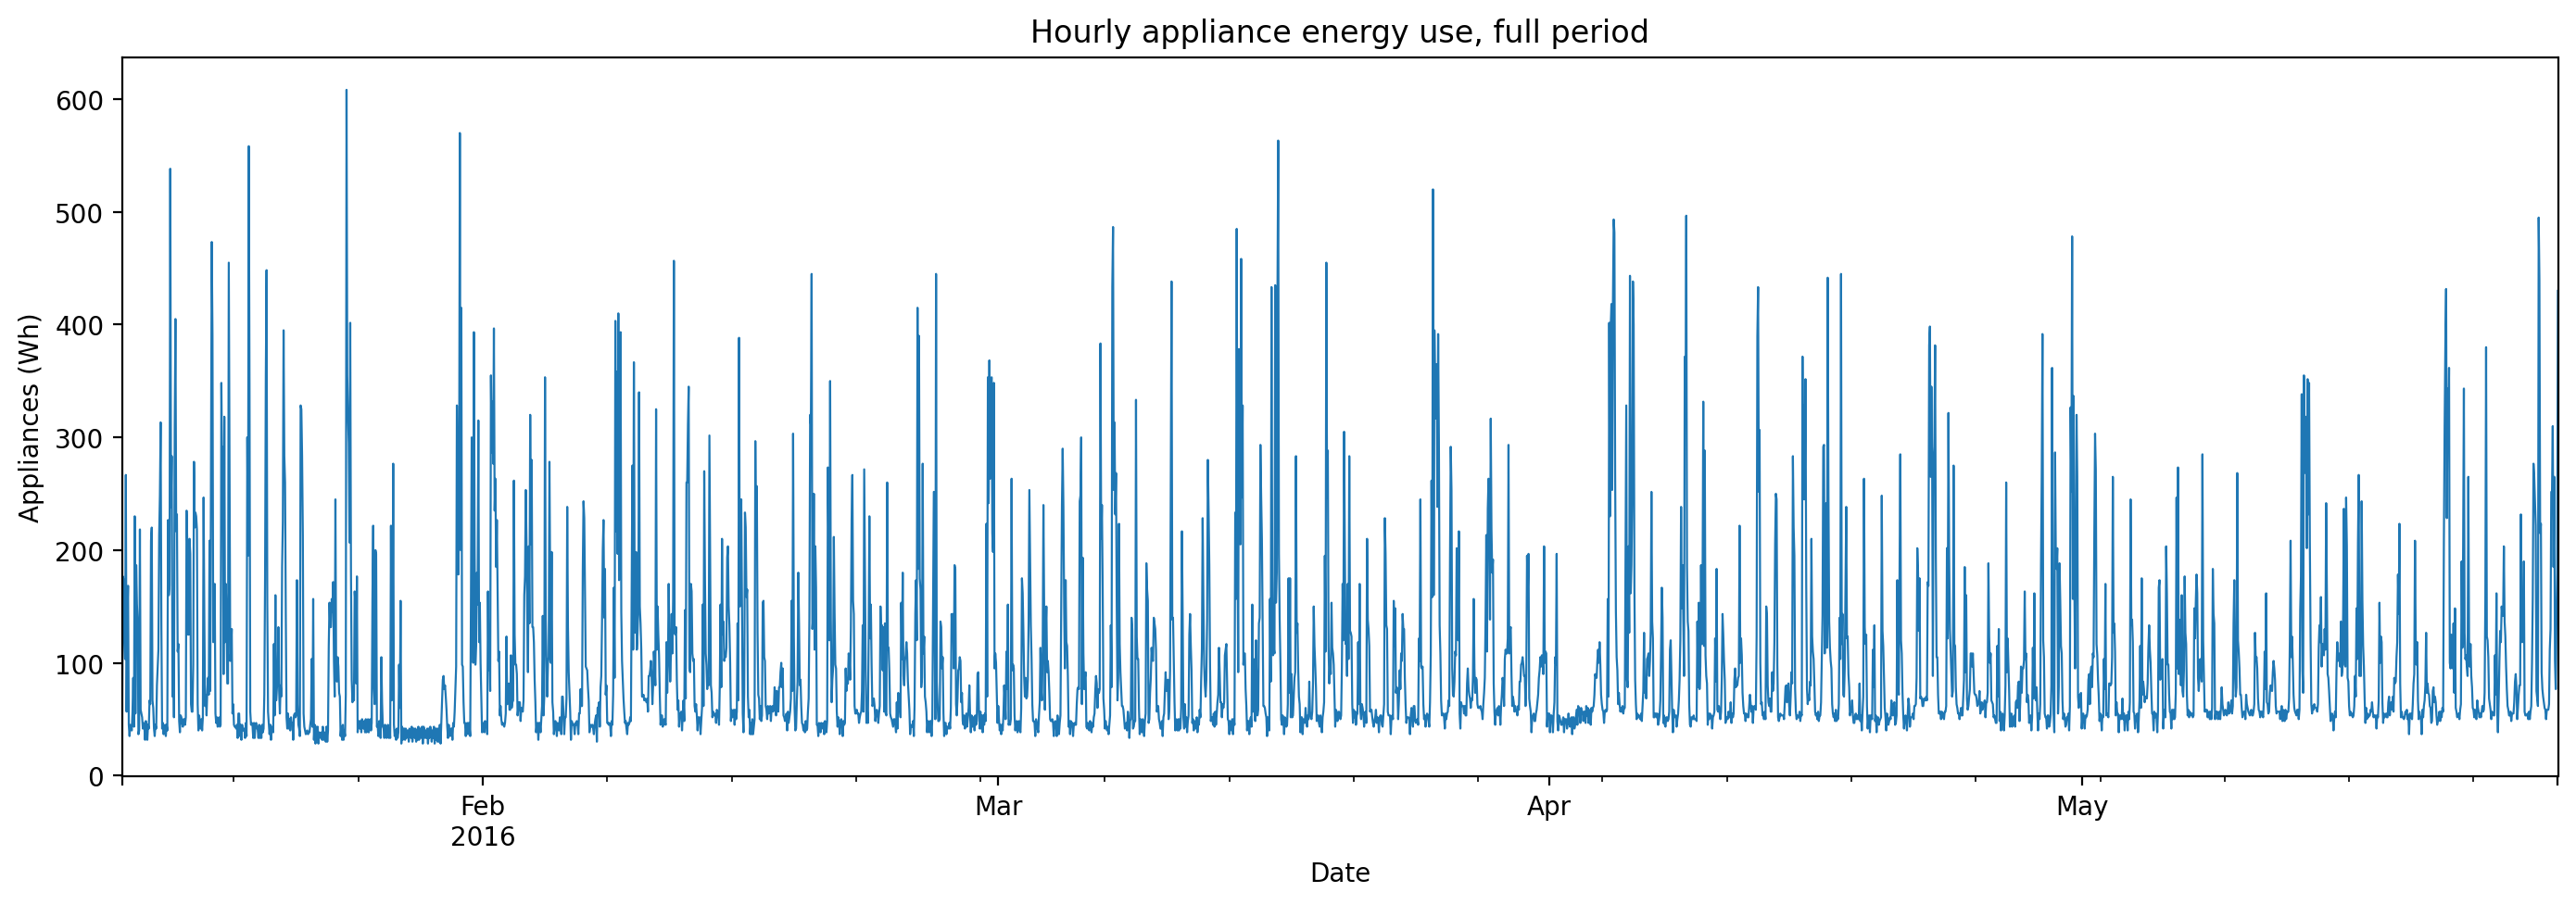

In [2]:
display(Image(filename='../outputs/figures/eda_full_series.png'))

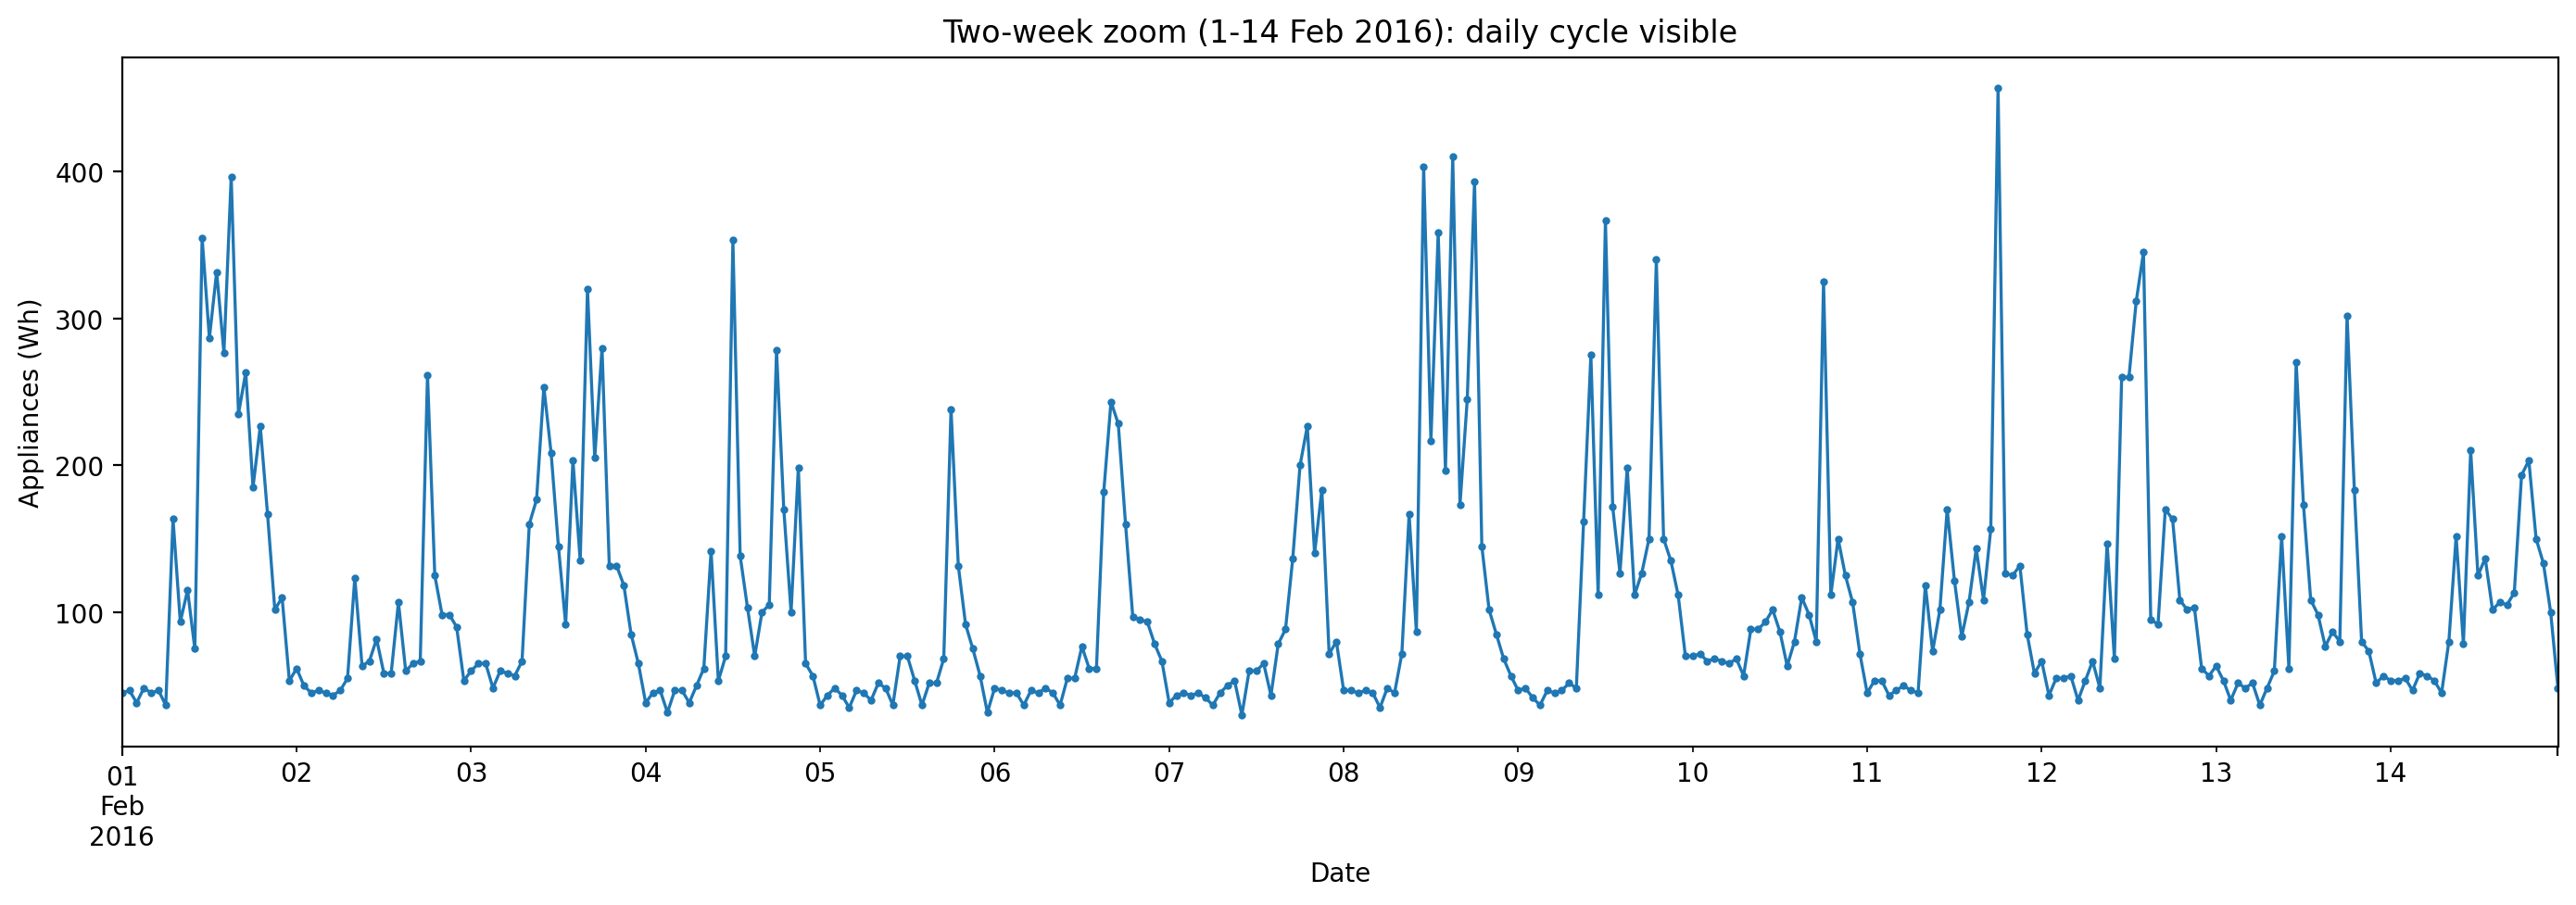

In [3]:
display(Image(filename='../outputs/figures/eda_seasonal_zoom.png'))

A clear daily on/off cycle is visible throughout, with occasional large, short-lived spikes from high-draw appliances.

## Hour-of-day and day-of-week patterns

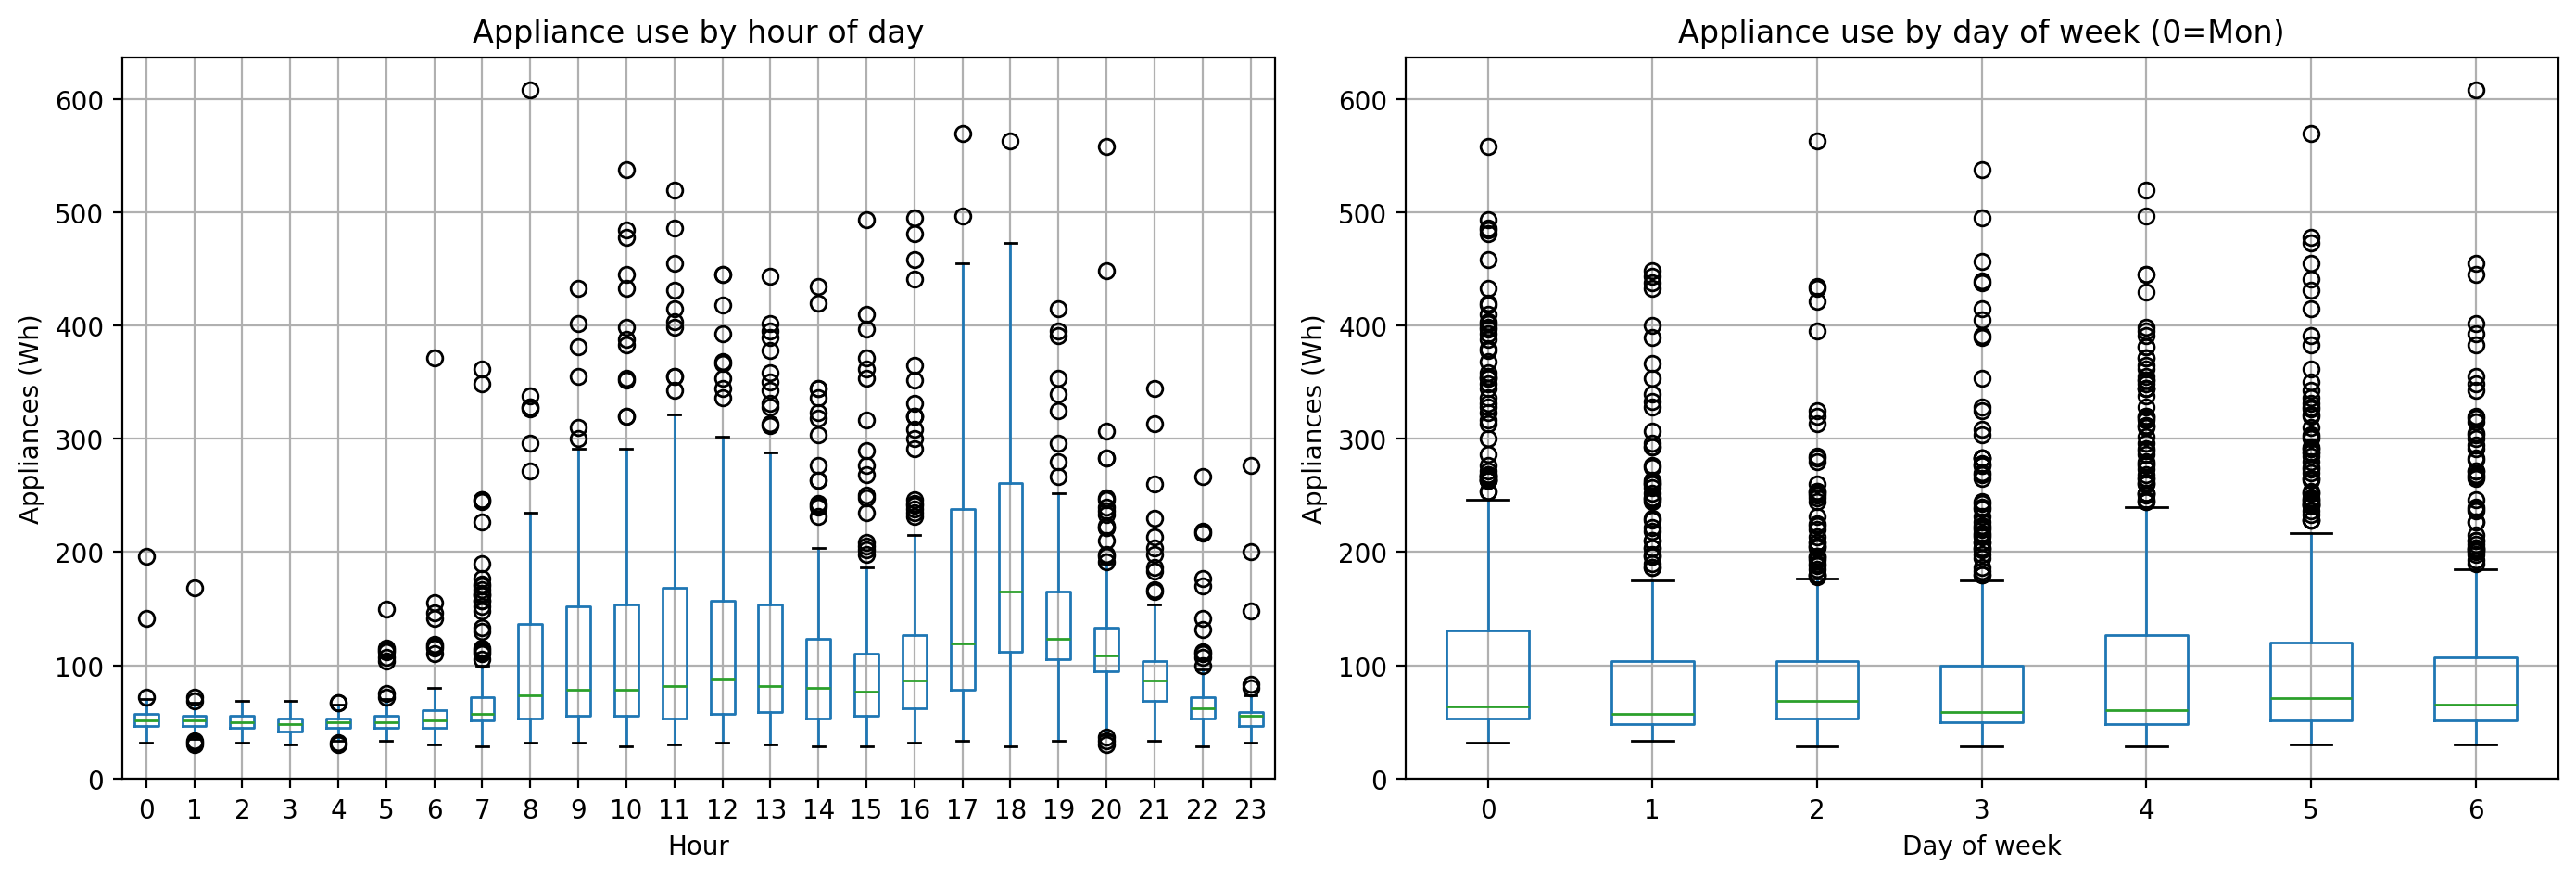

In [4]:
display(Image(filename='../outputs/figures/eda_hour_dow_boxplots.png'))

Hour-of-day is the dominant pattern (low overnight, peaking ~17:00–18:00); day-of-week shows a real but weaker effect (Fri/Sat somewhat higher).

## Seasonal decomposition

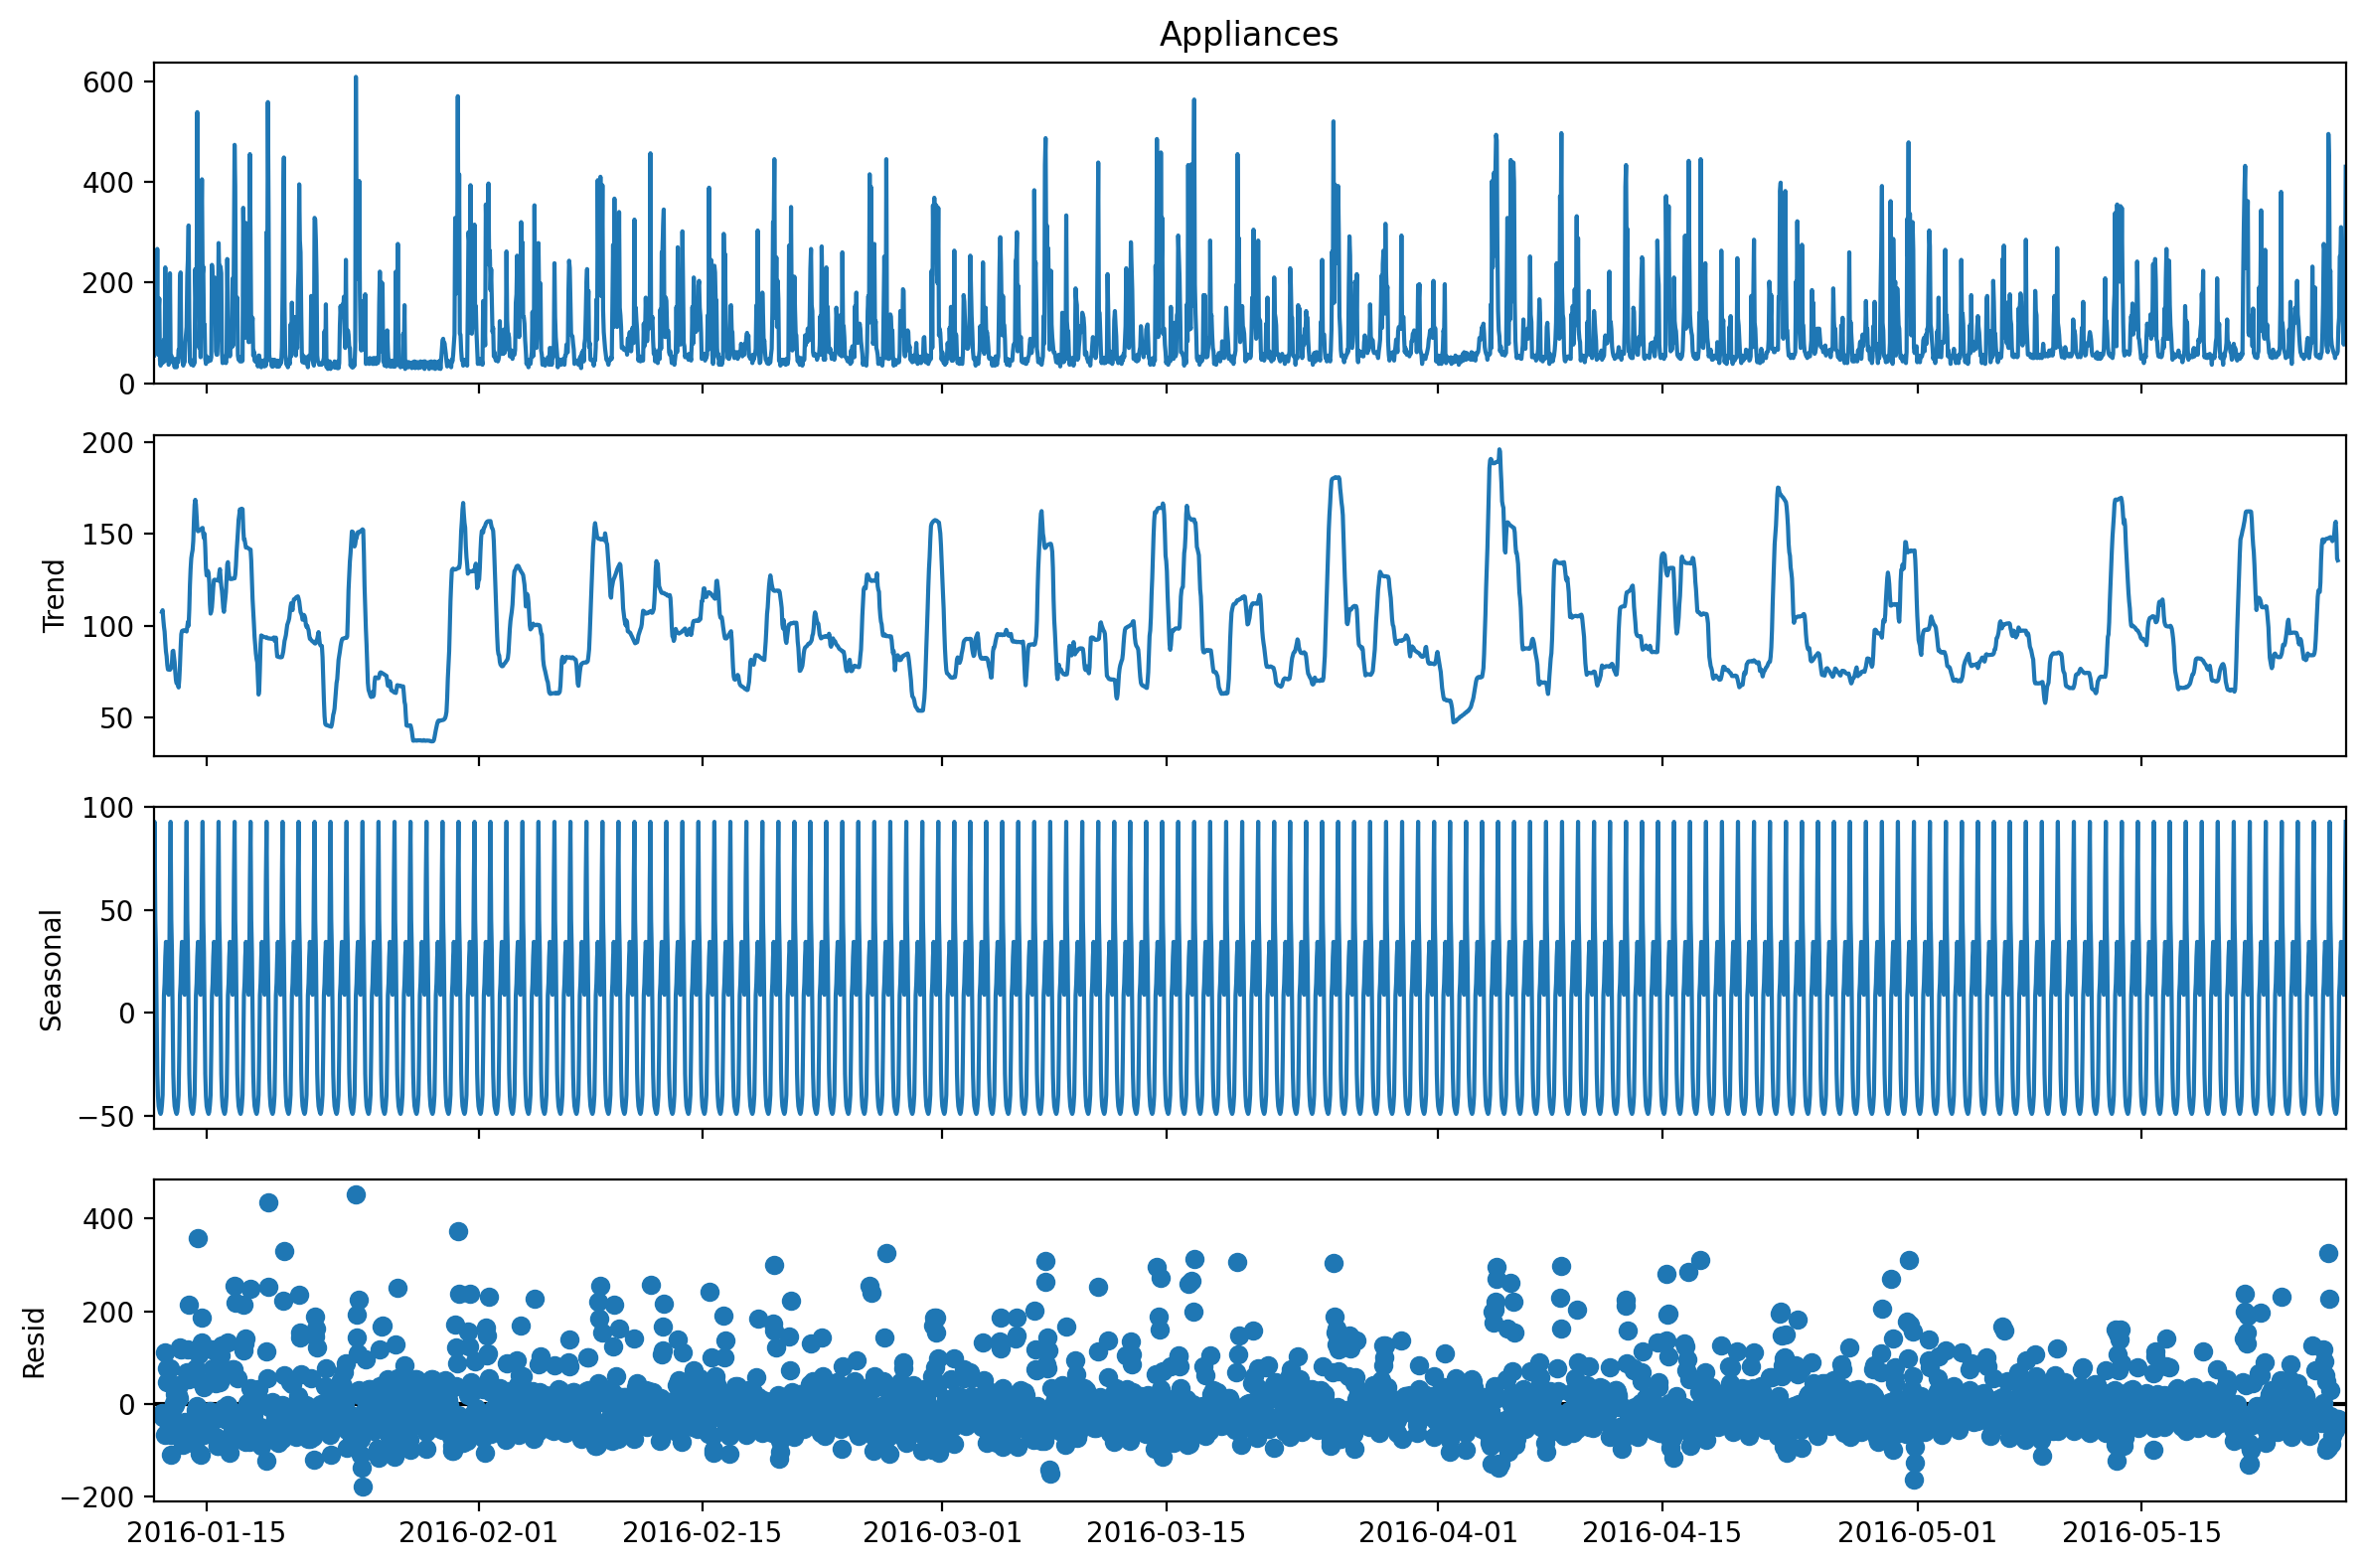

In [5]:
display(Image(filename='../outputs/figures/eda_seasonal_decompose.png'))

## Stationarity tests (ADF, KPSS)

In [6]:
print(open('../outputs/metrics/stationarity_summary.txt').read())

APPLIANCE ENERGY - EDA & STATIONARITY SUMMARY

Series length: 3290 hourly observations (2016-01-11 17:00:00 to 2016-05-27 18:00:00)

Descriptive statistics (Wh):
count    3290.000000
mean       97.779129
std        81.213695
min        28.333333
25%        50.000000
50%        63.333333
75%       110.000000
max       608.333333

Approx. seasonal strength (24h, additive decomposition): 0.284
Approx. trend strength: 0.200
(Strength close to 1 = component explains most of the variance left after removing the other components; Wang, Smith & Hyndman 2006 measure.)

--- Levels (Appliances, hourly) ---
ADF statistic: -8.9489
ADF p-value:   0.000000
ADF lags used: 29, nobs: 3260
ADF critical values: {'1%': np.float64(-3.432357502010421), '5%': np.float64(-2.862426994644342), '10%': np.float64(-2.567242166152283)}
ADF conclusion: stationary (reject H0)

KPSS statistic: 0.0384
KPSS p-value:   0.100000
KPSS lags used: 25
KPSS critical values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739

Both ADF and KPSS agree the raw hourly series is already stationary at levels — a finding revisited once SARIMAX order selection (which chose mild differencing, d=1) is discussed in notebook 04.